# Phase 6 — YOLOv8 Object Detection
Train · Validate · Run Inference on Aerial Images

In [8]:
# Install Ultralytics (run once)
import subprocess
subprocess.run(['pip', 'install', 'ultralytics', '-q'], check=True)
print('Ultralytics installed!')

Ultralytics installed!


In [ ]:
import os
import yaml
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

# ── Config ─────────────────────────────────────────────────────────
DETECT_ROOT = Path('object_detection_Dataset')  # <-- update if needed
YOLO_DIR    = Path('yolo_project')
YOLO_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ['bird', 'drone']   # class_id 0=bird, 1=drone
EPOCHS      = 50
IMG_SIZE    = 640
BATCH_SIZE  = 16

print('Detection dataset root:', DETECT_ROOT.resolve())

Detection dataset root: C:\Swayam\Codes\Internship\Aerial Object Detection\object_detection_dataset


## 6.1 — Inspect Detection Dataset

In [10]:
for split in ['train', 'valid', 'test']:
    img_dir   = DETECT_ROOT / split / 'images'
    label_dir = DETECT_ROOT / split / 'labels'
    imgs   = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')) if img_dir.exists() else []
    labels = list(label_dir.glob('*.txt')) if label_dir.exists() else []
    print(f'{split:6}: {len(imgs):4} images, {len(labels):4} label files')

# Show a sample annotation
sample_imgs = list((DETECT_ROOT / 'train' / 'images').glob('*.jpg'))[:1]
if sample_imgs:
    label_path = DETECT_ROOT / 'train' / 'labels' / (sample_imgs[0].stem + '.txt')
    if label_path.exists():
        print('\nSample annotation (', sample_imgs[0].name, '):')
        with open(label_path) as f:
            for line in f.readlines()[:3]:
                parts = line.strip().split()
                print(f'  class={CLASS_NAMES[int(parts[0])]:6} x_c={float(parts[1]):.3f} y_c={float(parts[2]):.3f} w={float(parts[3]):.3f} h={float(parts[4]):.3f}')

train : 2728 images, 2728 label files
valid :  448 images,  448 label files
test  :  224 images,  224 label files

Sample annotation ( 000596bc75926abe_jpg.rf.49cf79ededcab42c160f599b1104f421.jpg ):
  class=bird   x_c=0.793 y_c=0.319 w=0.044 h=0.028
  class=bird   x_c=0.815 y_c=0.292 w=0.050 h=0.024
  class=bird   x_c=0.831 y_c=0.263 w=0.059 h=0.032


## 6.2 — Visualize Bounding Box Annotations

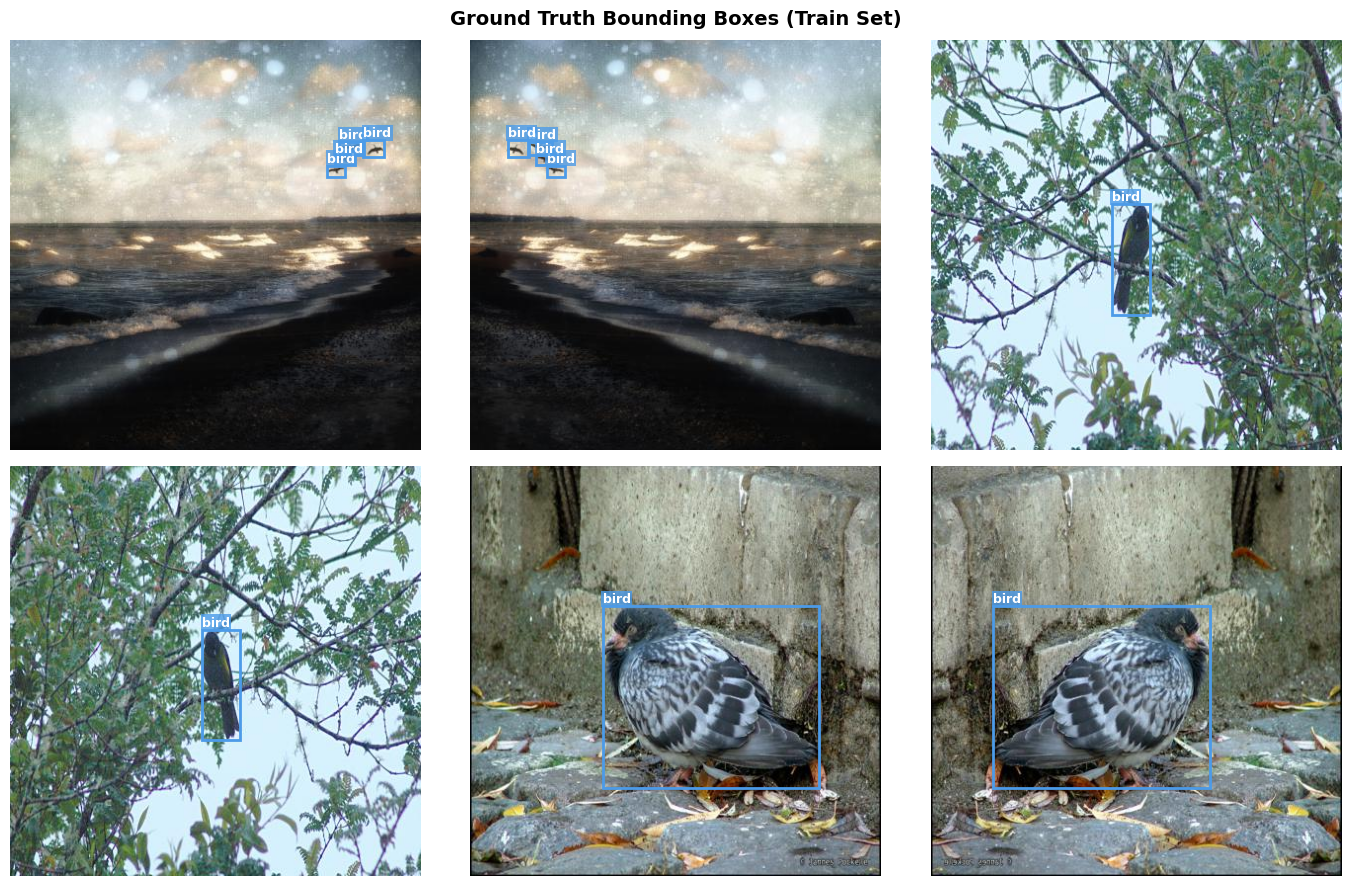

In [11]:
def draw_yolo_boxes(img_path, label_path, class_names, ax):
    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)
    colors = ['#4C9BE8', '#E8724C']
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                cls_id, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:5])
                x1 = (xc - bw/2) * W
                y1 = (yc - bh/2) * H
                rect = patches.Rectangle((x1, y1), bw*W, bh*H,
                                          linewidth=2, edgecolor=colors[cls_id],
                                          facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-4, class_names[cls_id],
                        color='white', fontsize=9, fontweight='bold',
                        bbox=dict(facecolor=colors[cls_id], alpha=0.8, pad=1, edgecolor='none'))
    ax.axis('off')

sample_imgs = list((DETECT_ROOT / 'train' / 'images').glob('*.jpg'))[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, img_path in zip(axes.flatten(), sample_imgs):
    label_path = DETECT_ROOT / 'train' / 'labels' / (img_path.stem + '.txt')
    draw_yolo_boxes(img_path, label_path, CLASS_NAMES, ax)

plt.suptitle('Ground Truth Bounding Boxes (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('yolo_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 — Create data.yaml for YOLOv8

In [12]:
data_yaml = {
    'path':  str(DETECT_ROOT.resolve()),
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc':    len(CLASS_NAMES),
    'names': CLASS_NAMES
}

yaml_path = YOLO_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print('data.yaml created:')
print(open(yaml_path).read())

data.yaml created:
names:
- bird
- drone
nc: 2
path: C:\Swayam\Codes\Internship\Aerial Object Detection\object_detection_dataset
test: test/images
train: train/images
val: valid/images



## 6.4 — Train YOLOv8

In [13]:
# Start with YOLOv8n (nano) for speed; use yolov8s or yolov8m for better accuracy
model = YOLO('yolov8n.pt')  # downloads pretrained weights automatically

results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project=str(YOLO_DIR),
    name='bird_drone_detector',
    patience=15,          # early stopping
    save=True,
    plots=True,
    verbose=True,
    # Augmentation
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    degrees=10,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4
)
print('YOLOv8 training complete!')

Ultralytics 8.4.38  Python-3.12.4 torch-2.8.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_project\data.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bird_drone_detector2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

## 6.5 — Validate Trained Model

In [14]:
# Load best weights
best_weights = str(YOLO_DIR / 'bird_drone_detector' / 'weights' / 'best.pt')
trained_model = YOLO(best_weights)

val_results = trained_model.val(
    data=str(yaml_path),
    split='val',
    verbose=True
)

print('\n=== Validation Metrics ===')
print(f'mAP50:    {val_results.box.map50:.4f}')
print(f'mAP50-95: {val_results.box.map:.4f}')
print(f'Precision: {val_results.box.mp:.4f}')
print(f'Recall:    {val_results.box.mr:.4f}')

Ultralytics 8.4.38  Python-3.12.4 torch-2.8.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 73.724.5 MB/s, size: 13.6 KB)
val: Scanning C:\Swayam\Codes\Internship\Aerial Object Detection\object_detection_dataset\valid\labels.cache... 448 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 448/448  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 1.8s/it 49.7s1.6ss
                   all        448        663      0.462      0.437       0.41      0.156
                  bird        217        414      0.364      0.331       0.27     0.0896
                 drone        225        249      0.561      0.542      0.549      0.222
Speed: 1.7ms preprocess, 93.8ms inference, 0.0ms loss, 8.5ms postprocess per image
Results saved to C:\Swayam\Codes\Proctoring Software\runs\detect\val

=== Validati

## 6.6 — Run Inference & Visualize Results

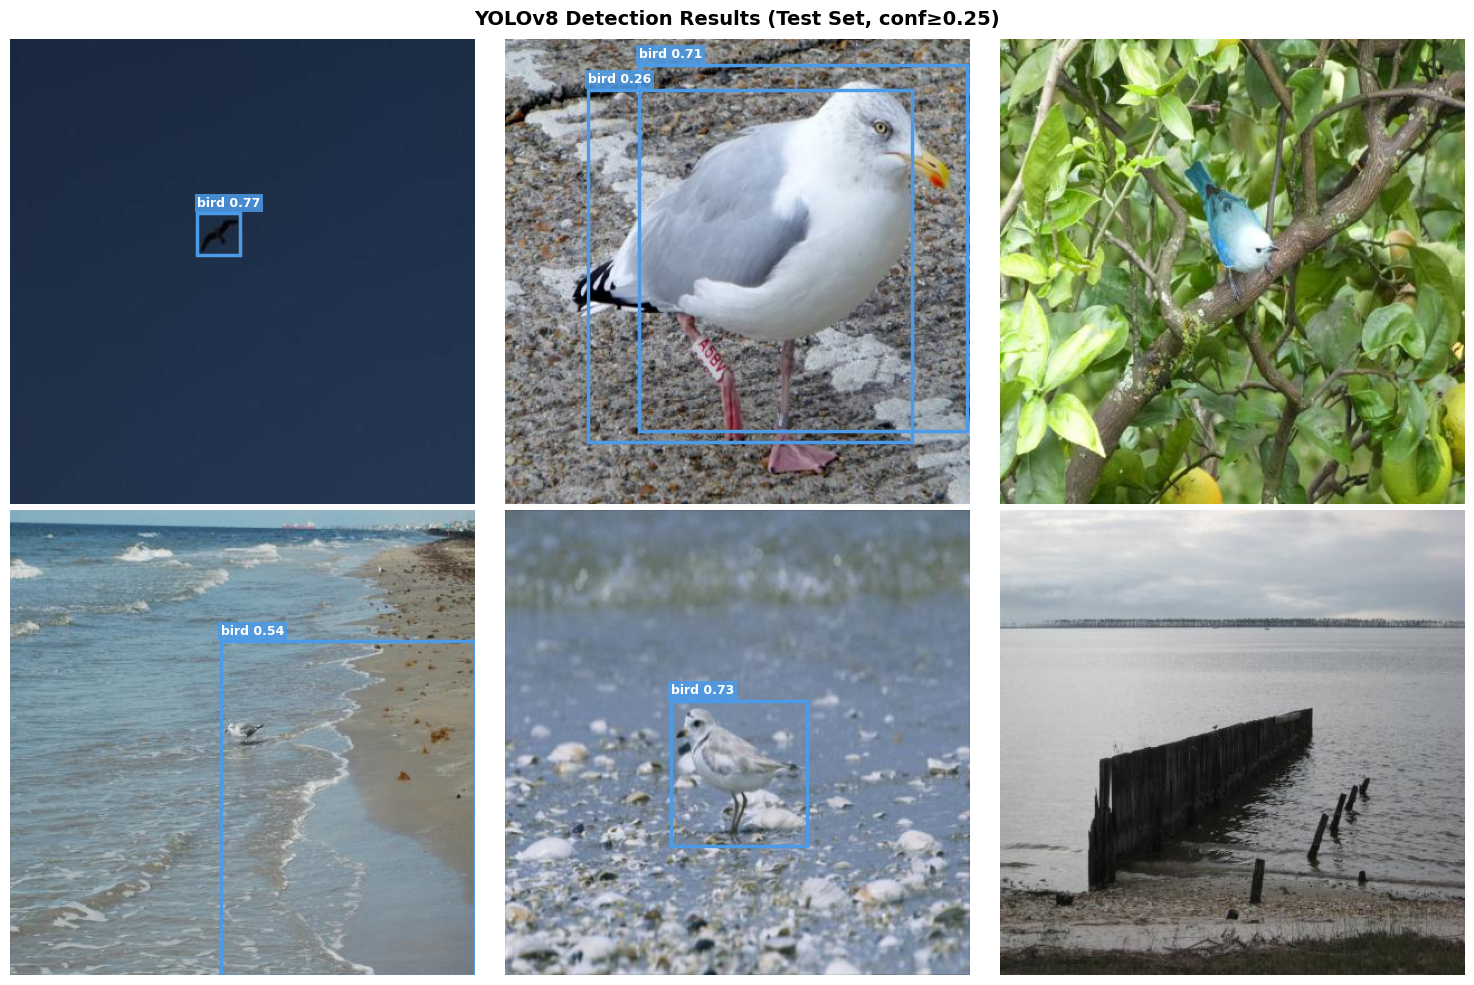

YOLO best weights saved as: yolo_best.pt
Phase 6 complete!


In [15]:
test_images = list((DETECT_ROOT / 'test' / 'images').glob('*.jpg'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
colors = {'bird': '#4C9BE8', 'drone': '#E8724C'}

for ax, img_path in zip(axes.flatten(), test_images):
    preds = trained_model.predict(str(img_path), conf=0.25, verbose=False)[0]
    img   = Image.open(img_path).convert('RGB')
    ax.imshow(img)

    if preds.boxes is not None:
        for box in preds.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            label  = CLASS_NAMES[cls_id]
            color  = colors[label]
            rect   = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                        linewidth=2.5, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-6, f'{label} {conf:.2f}',
                    color='white', fontsize=9, fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor='none'))
    ax.axis('off')

plt.suptitle('YOLOv8 Detection Results (Test Set, conf≥0.25)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('yolo_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Copy best weights to project root for Streamlit
import shutil
shutil.copy(best_weights, 'yolo_best.pt')
print('YOLO best weights saved as: yolo_best.pt')
print('Phase 6 complete!')